 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # 1 Implementation of Common Machine Learning Algorithms

 ## 1.1 Introduction

 ### 1.1.1 About This Lab

 This lab introduces common machine learning algorithms to help you better understand their functions and usages. Specifically, it will explain how to build a linear regression algorithm from scratch and implement the decision tree and K-means clustering based on scikit-learn.

 ## 1.2 Code Implementation

 ### 1.2.1 Linear Regression

 **Step 1: Import dependent packages.**

In [33]:
from sklearn.linear_model import LinearRegression # Import the linear regression model
import matplotlib.pyplot as plt # The plotting library
import numpy as np


 **Step 2: Build and visualize a house price dataset.**

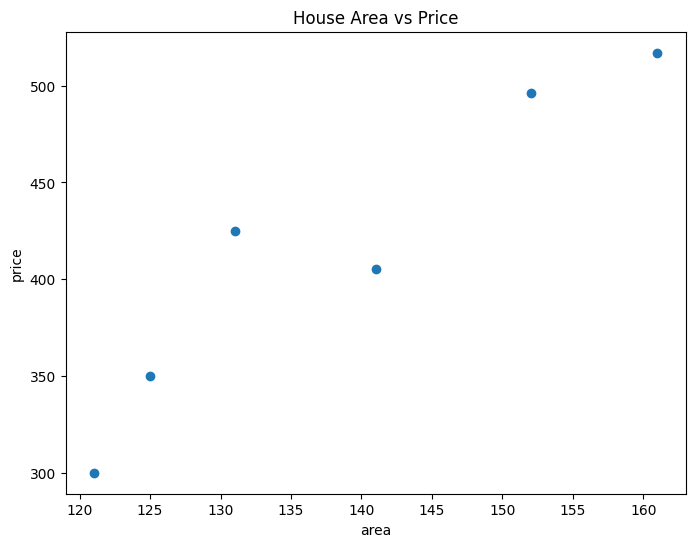

In [34]:
X = np.array([121, 125, 131, 141, 152, 161]).reshape(-1,1) # X denotes the house area as a feature.
y = np.array([300, 350, 425, 405, 496, 517]) # y denotes the house price.

plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.xlabel("area") # X axis indicates the area.
plt.ylabel("price") # Y axis indicates the price.
plt.title("House Area vs Price")
plt.show()


 **Step 3: Train the model.**

In [35]:
lr = LinearRegression()
lr.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


 **Step 4: Visualize the model.**

Slope: [4.98467124]
Intercept: -274.8769665187576


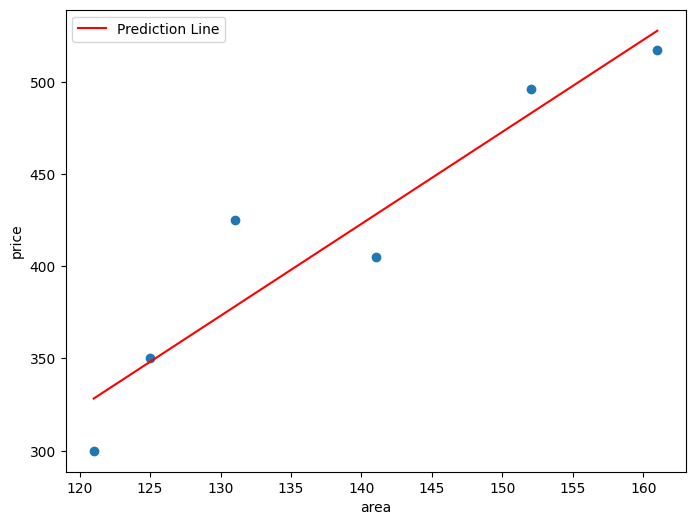

In [36]:
w = lr.coef_
b = lr.intercept_
print(f"Slope: {w}")
print(f"Intercept: {b}")

plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.xlabel("area") # X axis indicates the area.
plt.ylabel("price") # Y axis indicates the price.
# Plot regression line
plt.plot([X[0,0], X[-1,0]], [X[0,0]*w + b, X[-1,0]*w + b], color='red', label="Prediction Line")
plt.legend()
plt.show()


 **Step 5: Start a prediction task using the model.**

In [37]:
testX = np.array([[130]]) # A test sample with an area of 130
prediction = lr.predict(testX)
print(f"The model predicts the house price of the sample (area 130): {prediction}")



The model predicts the house price of the sample (area 130): [373.13029447]


 ### 1.2.2 Linear Regression Implementation (Expansion Experiment)

 This experiment uses simulated house area and price data.

 **Step 1: Import dependencies.**

In [38]:
import numpy as np
import matplotlib.pyplot as plt


 **Step 2 & 4: Define the functions for calculating gradients and initializing parameters.**

In [39]:
def generate_gradient(X, theta, y):
    m = X.shape[0]
    # Calculate gradient: X.T * (X * theta - y) / m
    return (1/m) * X.T.dot(X.dot(theta) - y)
    
def init_theta(feature_count):
    # Initialize the theta array.
    return np.ones(feature_count).reshape(feature_count, 1)


 **Step 3: Define the function for reading datasets.**

 Note: Instead of using `lr2_data.txt`, we will generate a synthetic dataset conforming to the tutorial structures.

In [40]:
def get_synthetic_training_data():
    # Synthetic data generation matching the structure mentioned
    np.random.seed(42)
    m = 100
    X_feature = np.linspace(1, 10, m).reshape((m, 1))
    # y = 3.0 * x + 1.6 + noise
    y_actual = 3.0 * X_feature + 1.6 + np.random.randn(m, 1) * 0.5
    X_ones = np.ones((m, 1))
    X_matrix = np.hstack((X_ones, X_feature)) # features with bias term
    return np.hstack((X_matrix, y_actual)), X_matrix, y_actual


 **Step 5: Define the function for implementing gradient descent.**

In [41]:
def gradient_descending(X, y, theta, alpha):
    Jthetas= [] # Record the change trend of the cost function J(theta)
    # Calculate the loss function -> J(theta) = (1/2m) * sum((X*theta - y)^2)
    m = len(y)
    Jtheta = (1/(2*m)) * (X.dot(theta)-y).T.dot(X.dot(theta)-y)
    index = 0
    gradient = generate_gradient(X, theta, y) # Calculate the gradient.
    
    while not np.all(np.absolute(gradient) <= 1e-5) and index < 15000: # Max iterations safeguard
        theta = theta - alpha * gradient
        gradient = generate_gradient(X, theta, y) # Calculate the new gradient.
        Jtheta = (1/(2*m)) * (X.dot(theta)-y).T.dot(X.dot(theta)-y)
        if (index+1) % 10 == 0:
            Jthetas.append((index, Jtheta[0, 0])) # Record the result every 10 calculations.
        index += 1
    return theta, Jthetas


 **Step 6 & 7: Functions for visualizing the change curve of the loss function and fitted curve**

In [42]:
def showJTheta(Jthetas):
    steps = [item[0] for item in Jthetas]
    loss = [item[1] for item in Jthetas]
    plt.figure()
    plt.plot(steps, loss)
    plt.xlabel('steps')
    plt.ylabel('loss')
    plt.title('step - loss function curve')
    plt.show()

def showlinercurve(theta, sample_training_set):
    x, y = sample_training_set[:, 1], sample_training_set[:, 2]
    z = theta[0] + theta[1] * x
    plt.figure()
    plt.scatter(x, y, color='b', marker='x', label="sample data")
    plt.plot(x, z, 'r', color="r", label="regression curve")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('liner regression curve')
    plt.legend()
    plt.show()


 **Step 8: Plot the final results.**

w: 3.007671126048613 b: 1.505875551901159


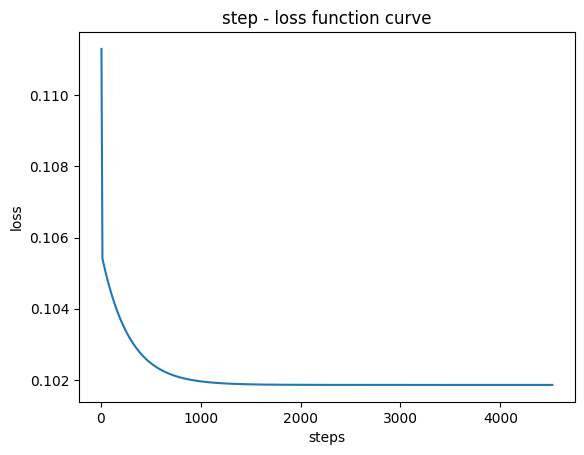

/tmp/ipykernel_832289/521603752.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, z, 'r', color="r", label="regression curve")


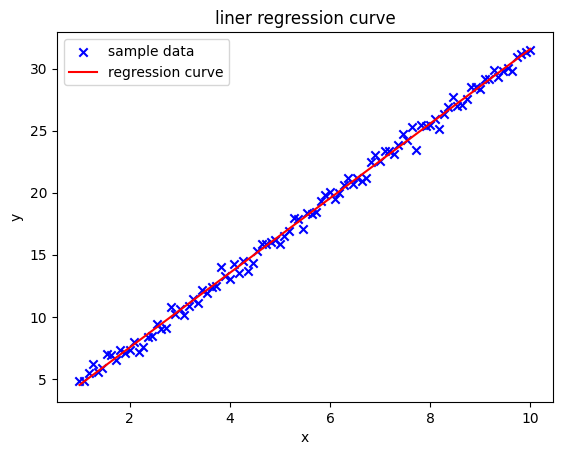

In [43]:
# Read the synthetic dataset.
training_data_include_y, training_x, y_train = get_synthetic_training_data()
# Obtain the numbers of samples and features, respectively.
sample_count, feature_count = training_x.shape
# Define the learning step alpha.
alpha = 0.01

# Initialize theta.
theta = init_theta(feature_count)

# Obtain the final parameter theta and cost.
result_theta, Jthetas = gradient_descending(training_x, y_train, theta, alpha)

# Display the parameter.
print(f"w: {result_theta[1][0]} b: {result_theta[0][0]}")
showJTheta(Jthetas)
showlinercurve(result_theta, training_data_include_y)



 ### 1.2.3 Logistic Regression

 **Step 1 & 2: Import dependencies and Define the dataset.**

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Each item in X denotes the rent and area.
# y indicates whether to rent the room (0: no; 1: yes).
X=[[2200,15],[2750,20],[5000,40],[4000,20],[3300,20],[2000,10],[2500,12],[12000,80],
   [2880,10],[2300,15],[1500,10],[3000,8],[2000,14],[2000,10],[2150,8],[3400,20],
   [5000,20],[4000,10],[3300,15],[2000,12],[2500,14],[10000,100],[3150,10],
   [2950,15],[1500,5],[3000,18],[8000,12],[2220,14],[6000,100],[3050,10]]

y=[1,1,0,0,1,1,1,1,0,1,1,0,1,1,0,1,0,0,0,1,1,1,0,1,0,1,0,1,1,0]


 **Step 3 & 4: Preprocess and Fit data.**

In [45]:
ss = StandardScaler()
X_train = ss.fit_transform(X)

print("\nStandardized Training Data:\n", X_train[:5]) # Displaying partial

# Use the fit method of LogisticRegression to train model parameters.
lr_log = LogisticRegression()
lr_log.fit(X_train, y)



Standardized Training Data:
 [[-0.60583897 -0.29313058]
 [-0.37682768 -0.09050576]
 [ 0.56003671  0.71999355]
 [ 0.14365254 -0.09050576]
 [-0.14781638 -0.09050576]]


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

 **Step 5: Predict the data.**

In [46]:
testX = [[2000,8]]
X_test = ss.transform(testX)
print("Value to be predicted: ", X_test)
label = lr_log.predict(X_test)
print("predicted label = ", label)
# Output the predicted probability.
prob = lr_log.predict_proba(X_test)
print("probability = ", prob)



Value to be predicted:  [[-0.68911581 -0.57680534]]
predicted label =  [1]
probability =  [[0.41882379 0.58117621]]


 ### 1.2.4 Decision Tree

 Due to the missing `tennis.txt` dataset file, an inline mock pandas dataframe is constructed reflecting typical PlayTennis datasets.

In [47]:
import pandas as pd
import numpy as np
from sklearn import tree
import pydotplus
# To avoid missing Graphviz error on local machines, we also use tree.plot_tree
import matplotlib.pyplot as plt

# Mock data mapping 
tennis_data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(tennis_data)


 **Vectorize Data and Generates Tree**

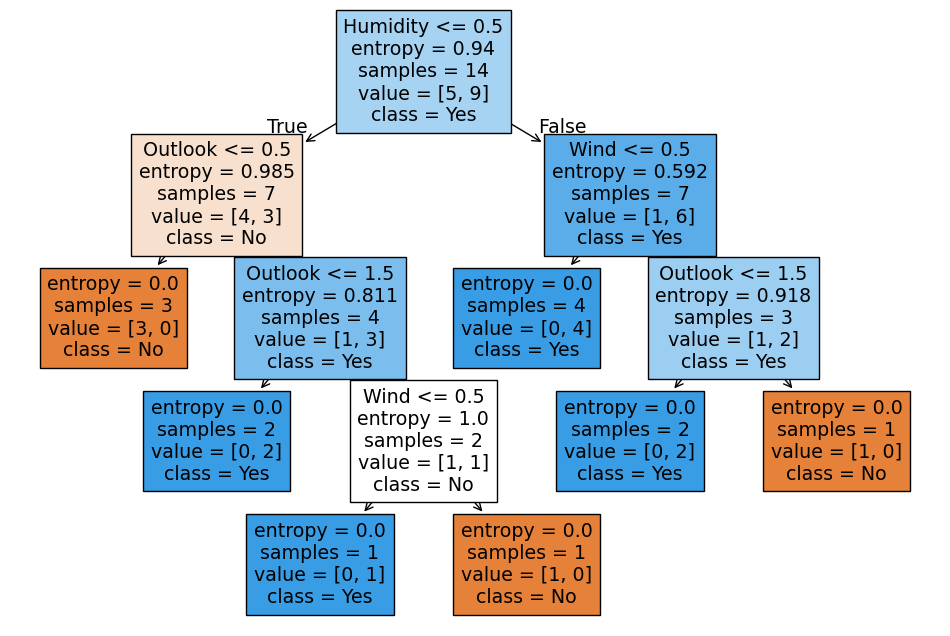

Prediction for new sample: [1]


/home/ansinitro/AITU/ai-nn/midterm/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [48]:
# Convert categorical strings to integers
df_encoded = df.apply(lambda x: pd.factorize(x)[0])

X_features = df_encoded.iloc[:, :-1]
y_target = df_encoded.iloc[:, -1]

decisionTree = tree.DecisionTreeClassifier(criterion='entropy')
decisionTree = decisionTree.fit(X_features, y_target)

plt.figure(figsize=(12,8))
tree.plot_tree(decisionTree, feature_names=X_features.columns.tolist(), class_names=['No', 'Yes'], filled=True)
plt.show()

# Predict a new sample
testVec = np.array([0, 0, 1, 1]).reshape(1, -1) # Sunny, Hot, Normal, Strong (based on encodings)
print("Prediction for new sample:", decisionTree.predict(testVec))



 ### 1.2.5 K-means Algorithm Implementation

 **Step 1 & 2: Import dependencies and Generate the dataset.**

In [49]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# make_blobs is used to generate a dataset by returning generated dataset and labels
X_blob, y_blob = make_blobs(n_samples=500, n_features=2, centers=4, random_state=1)

print("Dimension of X is", X_blob.shape)
print("Dimension of y is", y_blob.shape)


Dimension of X is (500, 2)
Dimension of y is (500,)


 **Step 3 & 4: Draw scatter graphs and Perform k-means clustering (k=3).**

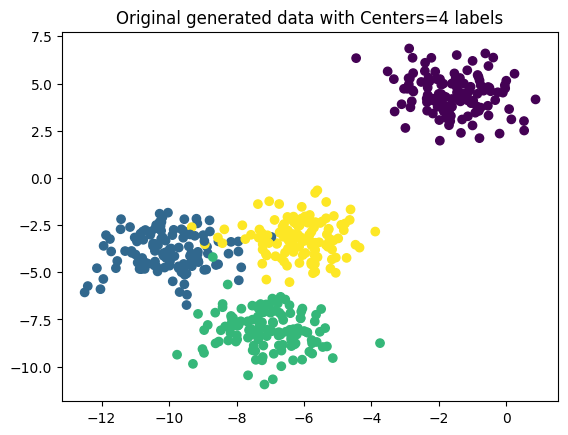

Centroids (3 clusters):
 [[-1.54234022  4.43517599]
 [-8.08734194 -3.49920867]
 [-7.10664372 -8.07416549]]


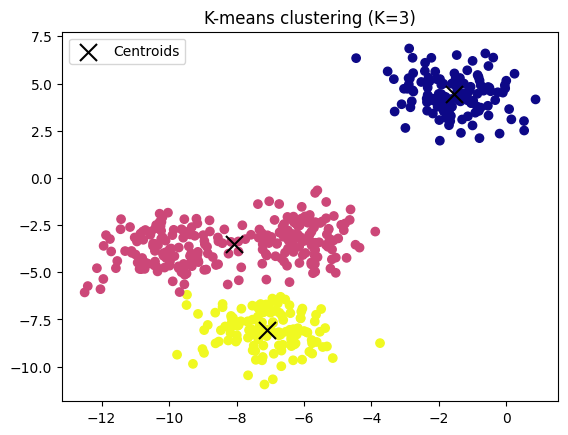

In [50]:
plt.figure()
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='viridis', marker='o')
plt.title("Original generated data with Centers=4 labels")
plt.show()

# Perform k-means clustering with 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=0)
cluster_labels_3 = kmeans_3.fit_predict(X_blob)

centroid_3 = kmeans_3.cluster_centers_
print("Centroids (3 clusters):\n", centroid_3)

plt.figure()
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=cluster_labels_3, cmap='plasma', marker='o')
plt.scatter(centroid_3[:, 0], centroid_3[:, 1], marker="x", s=150, c="black", label='Centroids')
plt.title("K-means clustering (K=3)")
plt.legend()
plt.show()


 **Step 5: Perform k-means clustering again (k=4).**

Centroids (4 clusters):
 [[ -6.08459039  -3.17305983]
 [-10.00969056  -3.84944007]
 [ -7.09306648  -8.10994454]
 [ -1.54234022   4.43517599]]


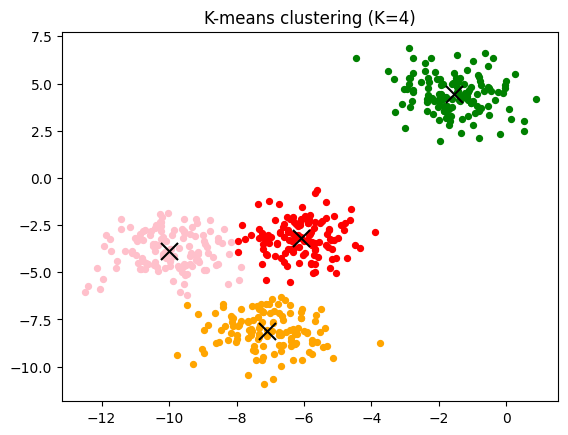

In [51]:
n_clusters = 4
kmeans_4 = KMeans(n_clusters=n_clusters, random_state=0).fit(X_blob)
y_pred_4 = kmeans_4.labels_
centroid_4 = kmeans_4.cluster_centers_
print("Centroids (4 clusters):\n", centroid_4)

color = ["red", "pink", "orange", "green"]

plt.figure()
for i in range(n_clusters):
    plt.scatter(X_blob[y_pred_4 == i, 0], X_blob[y_pred_4 == i, 1], marker='o', s=18, c=color[i])

plt.scatter(centroid_4[:, 0], centroid_4[:, 1], marker="x", s=150, c="black")
plt.title("K-means clustering (K=4)")
plt.show()
